In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
import numpy as np

In [3]:
import pyodbc

conn = pyodbc.connect(
    "Driver={ODBC Driver 18 for SQL Server};"
    "Server=DESKTOP-55JNORK\\SQLEXPRESS;"
    "Database=phonepe;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

cursor = conn.cursor()
print("Connected Successfully!")

Connected Successfully!


# 1. Decoding Transaction Dynamics on PhonePe

Analyze registered users and app opens based on device brands,
states, years, and quarters.

## Scenario

PhonePe has identified variations in transaction behavior across
states, quarters, and payment categories.

This analysis helps understand transaction performance and
identify important regions and transaction categories.

## Objective

- Identify top-performing states.
- Analyze transaction categories.
- Compare transaction amounts across states.
- Understand transaction distribution.
- Identify opportunities for targeted business strategies.

### Load & understand the data

In [4]:
query = """
SELECT *
FROM aggregated_transaction;
"""

df = pd.read_sql(query, conn)

df.head()

C:\Users\Devendra\AppData\Local\Temp\ipykernel_26896\1810234610.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,States,Years,Quarter,Transaction_type,Transaction_count,Transaction_amount
0,Assam,2023,1,Financial Services,82270,86978703
1,Assam,2023,1,Others,116656,74768264
2,Assam,2023,2,Merchant payments,62403711,45515248236
3,Assam,2023,2,Peer-to-peer payments,57852989,182809282981
4,Assam,2023,2,Recharge & bill payments,17858409,6631355080


In [9]:
df.shape

(20136, 6)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20136 entries, 0 to 20135
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   States              20136 non-null  str  
 1   Years               20136 non-null  int64
 2   Quarter             20136 non-null  int64
 3   Transaction_type    20136 non-null  str  
 4   Transaction_count   20136 non-null  int64
 5   Transaction_amount  20136 non-null  int64
dtypes: int64(4), str(2)
memory usage: 1.4 MB


In [11]:
print(df.isnull().sum())

States                0
Years                 0
Quarter               0
Transaction_type      0
Transaction_count     0
Transaction_amount    0
dtype: int64


#### Overall Transaction KPIs

In [17]:
total_transactions = df["Transaction_count"].sum()
total_amount = df["Transaction_amount"].sum()

print("Total Transaction Count:", total_transactions)
print("Total Transaction Amount:", total_amount)

Total Transaction Count: 941136867496
Total Transaction Amount: 1382089179334392


# Top 10 states

C:\Users\Devendra\AppData\Local\Temp\ipykernel_26896\1066016665.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_trans = pd.read_sql(query, conn)


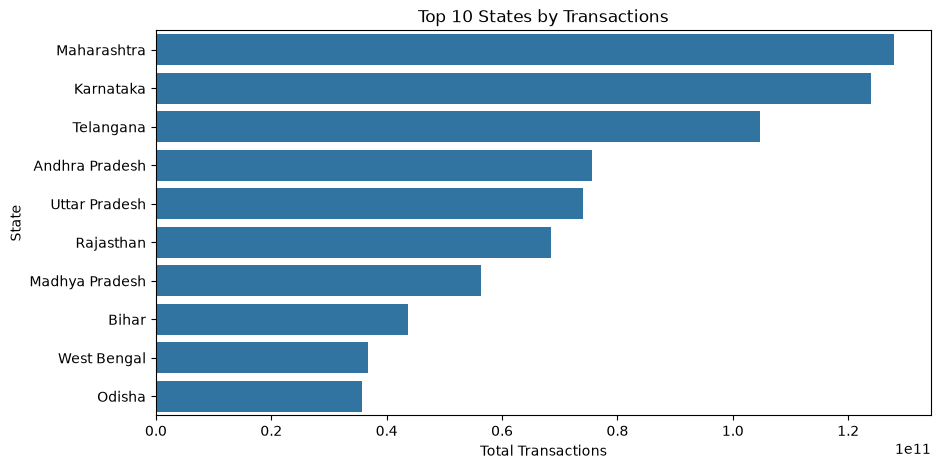

In [5]:
query = """
SELECT TOP 10
    States,
    SUM(Transaction_count) AS Total_Transactions
FROM aggregated_transaction
GROUP BY States
ORDER BY Total_Transactions DESC
"""

df_trans = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
sns.barplot(data=df_trans, x="Total_Transactions", y="States")

plt.title("Top 10 States by Transactions")
plt.xlabel("Total Transactions")
plt.ylabel("State")
plt.show()

### Which states have the highest number of PhonePe transactions.

### Insight:

A few states contribute a large share of total transactions, showing stronger PhonePe usage in those regions.

### Recommendation:

Focus marketing and merchant partnerships in high-transaction states and improve adoption in low-transaction states.

### Top 10 States by Transaction Amount

C:\Users\Devendra\AppData\Local\Temp\ipykernel_26896\1661912082.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_amount = pd.read_sql(query, conn)


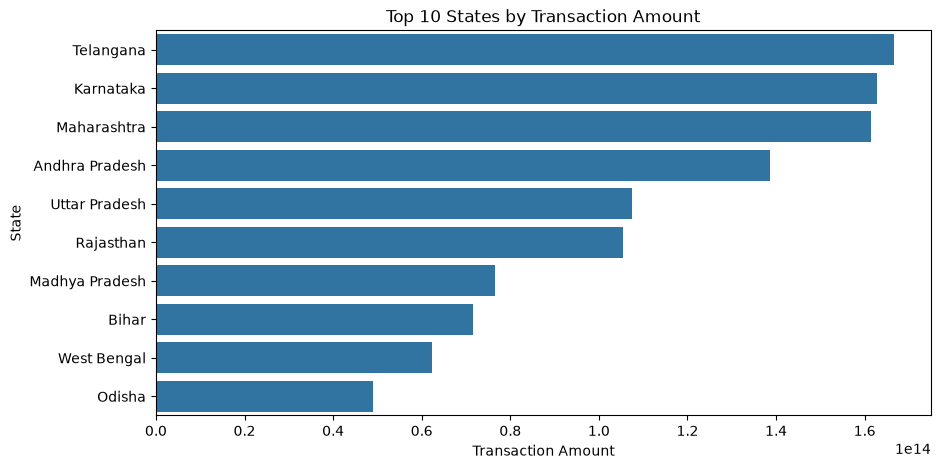

In [6]:
query = """
SELECT TOP 10
    States,
    SUM(Transaction_amount) AS Total_Amount
FROM aggregated_transaction
GROUP BY States
ORDER BY Total_Amount DESC
"""

df_amount = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
sns.barplot(data=df_amount, x="Total_Amount", y="States")

plt.title("Top 10 States by Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("State")
plt.show()

#### Which states generate the highest transaction value.

### Insight:

Some states generate higher transaction values, indicating stronger payment activity and business potential.

### Recommendation:

Prioritize these states for partnerships and premium financial services.

### Transaction Growth Over Years

C:\Users\Devendra\AppData\Local\Temp\ipykernel_26896\3952715288.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_year = pd.read_sql(query, conn)


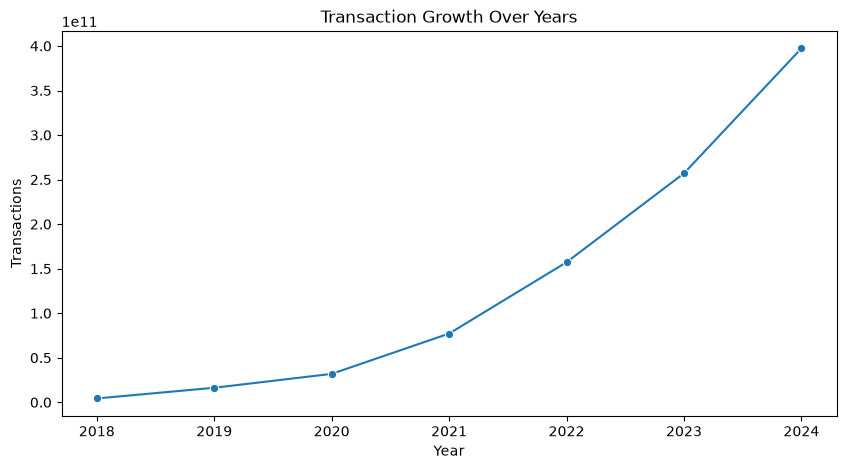

In [8]:
query = """
SELECT
    Years,
    SUM(Transaction_count) AS Total_Transactions
FROM aggregated_transaction
GROUP BY Years
ORDER BY Years
"""

df_year = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
sns.lineplot(
    data=df_year,
    x="Years",
    y="Total_Transactions",
    marker="o"
)

plt.title("Transaction Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Transactions")
plt.show()

#### How PhonePe transactions change over time.

#### Insight:

The overall transaction trend shows how PhonePe's usage has grown across the years.

#### Recommendation:

Continue customer engagement, offers, and merchant expansion to maintain transaction growth.

### Conclusion

PhonePe transactions are growing, with some states showing higher transaction activity than others. PhonePe can focus on high-performing states and improve marketing in low-performing states to increase overall transactions and market growth.